In [42]:
# Imports
import sys
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Get the notebook directory and navigate to project root
notebook_dir = Path(os.getcwd())
if notebook_dir.name == "notebooks":
    REPO_ROOT = notebook_dir.parent
else:
    REPO_ROOT = notebook_dir

sys.path.append(str(REPO_ROOT))

In [43]:
# Load data
costs = pd.read_csv(REPO_ROOT / "data/costs_2030.csv")
timeseries = pd.read_csv(REPO_ROOT / "data/time_series_2030.csv", index_col=0, parse_dates=True)

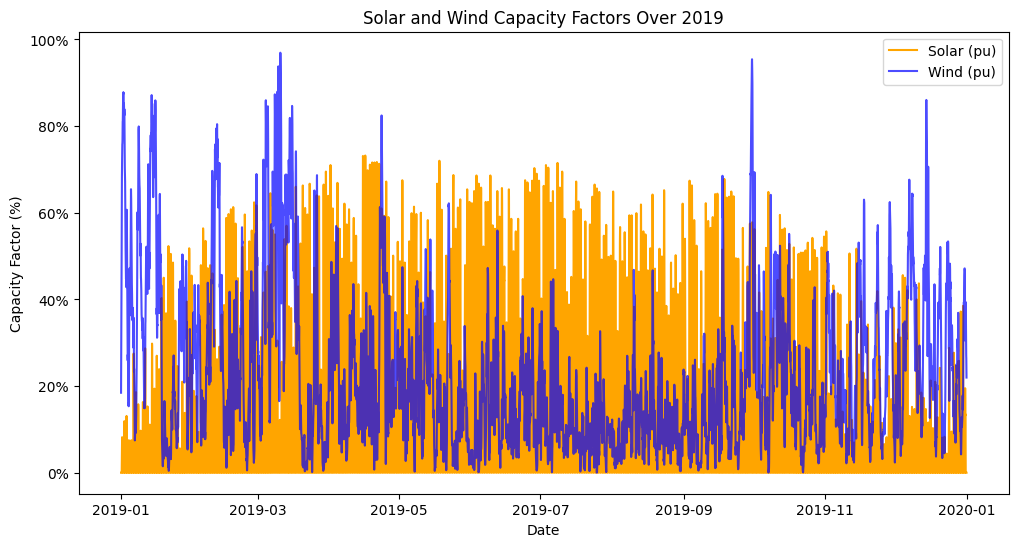

In [44]:
# Plot timeseries data with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot pv_pu and wind_pu on left axis
ax1.plot(timeseries.index, timeseries["pv_pu"], label="Solar (pu)", color="orange")
ax1.plot(timeseries.index, timeseries["wind_pu"], label="Wind (pu)", color="blue", alpha=0.7)
ax1.set_xlabel("Date")
ax1.set_ylabel("Capacity Factor (%)", color="black")
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.tick_params(axis="y")
ax1.legend()

plt.title("Solar and Wind Capacity Factors Over 2019")
plt.show()

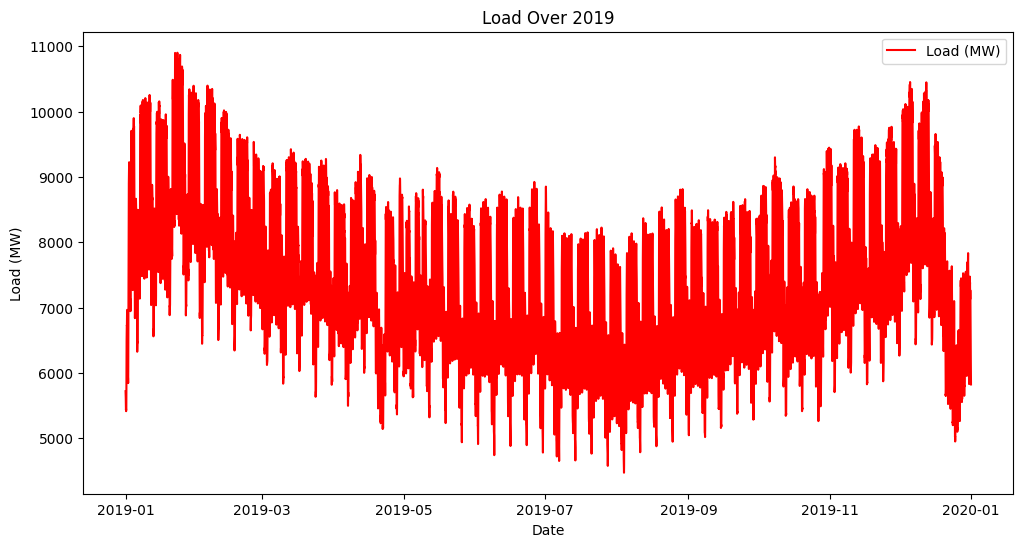

In [45]:
# Plot timeseries data with dual y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot pv_pu and wind_pu on left axis
ax1.plot(timeseries.index, timeseries["load_mw"], label="Load (MW)", color="red")
ax1.set_xlabel("Date")
ax1.set_ylabel("Load (MW)", color="black")
ax1.tick_params(axis="y")
ax1.legend()

plt.title("Load Over 2019")
plt.show()

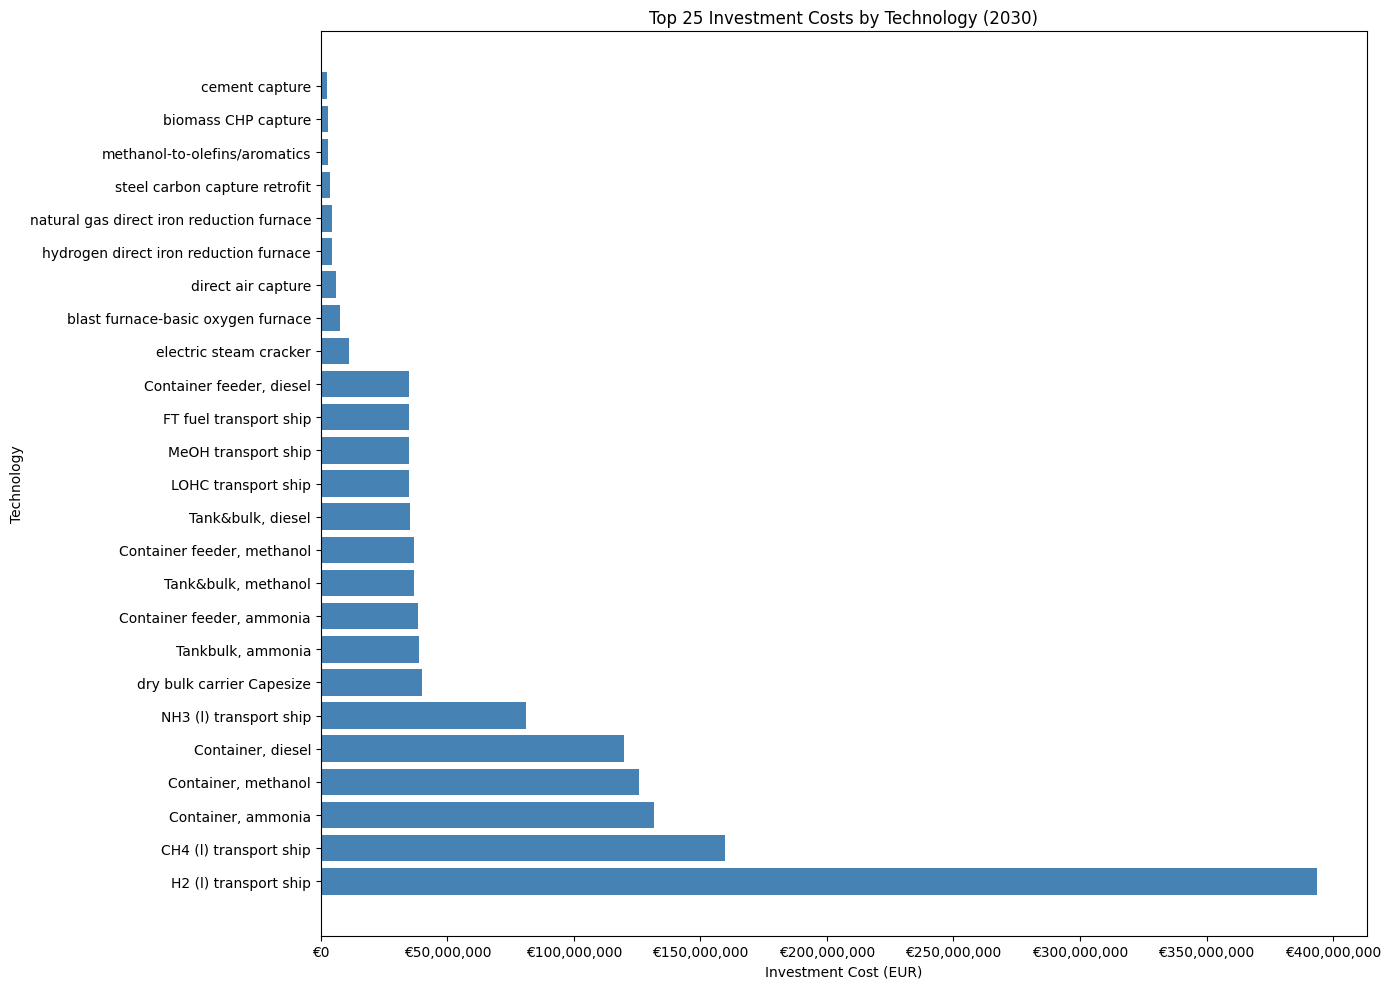

In [46]:
n_top_investment = 25

# Bar chart of investment costs by technology
investment_df = costs[costs["parameter"] == "investment"].copy()
top_n_investment_df = investment_df.sort_values("value", ascending=False).head(n_top_investment)

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(top_n_investment_df["technology"], top_n_investment_df["value"], color="steelblue")
ax.set_xlabel("Investment Cost (EUR)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{x:,.0f}"))
ax.set_ylabel("Technology")
ax.set_title(f"Top {n_top_investment} Investment Costs by Technology (2030)")
plt.tight_layout()
plt.show()

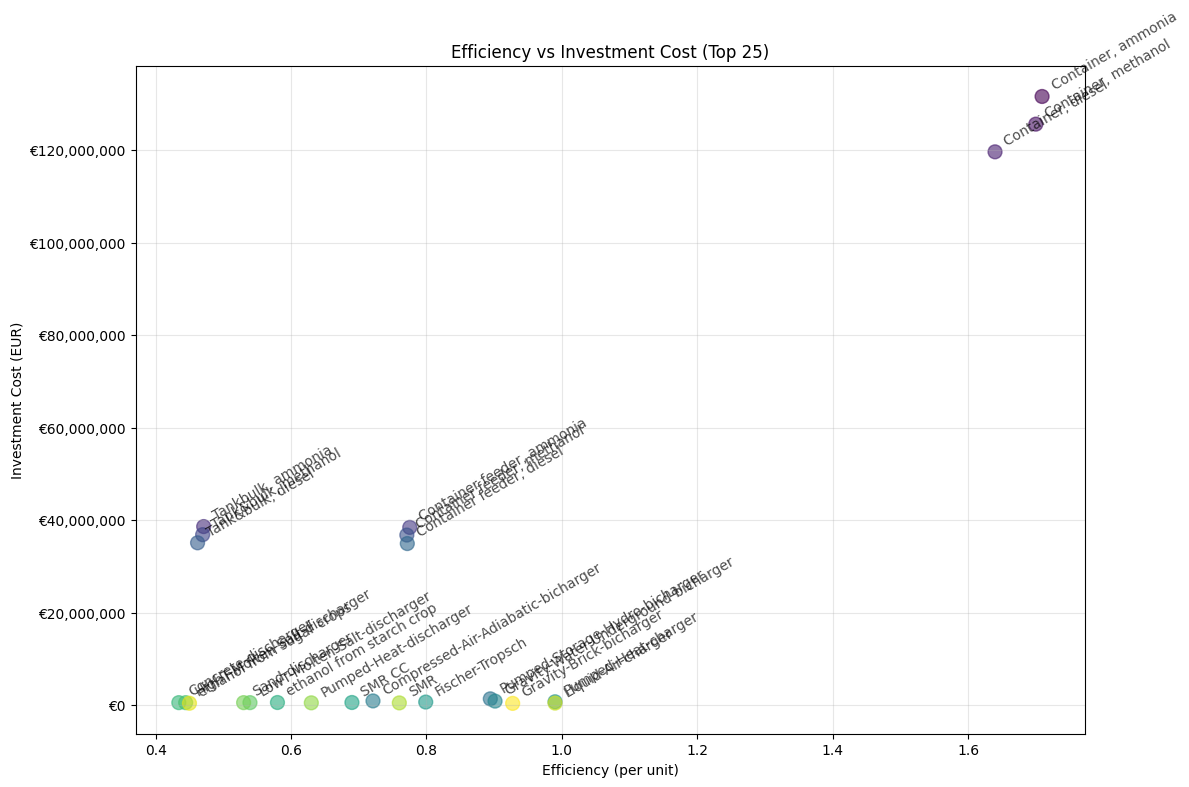

In [ ]:
# Scatter plot of efficiency vs investment cost
# Get efficiency and investment data
efficiency_df = costs[costs["parameter"] == "efficiency"][["technology", "value"]].rename(
    columns={"value": "efficiency"}
)
investment_df = costs[costs["parameter"] == "investment"][["technology", "value"]].rename(
    columns={"value": "investment"}
)

# Merge the two datasets
merged_df = pd.merge(efficiency_df, investment_df, on="technology", how="inner")

# Get top n_top_investment by investment cost
top_n_merged = merged_df.nlargest(n_top_investment, "investment")

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    top_n_merged["efficiency"],
    top_n_merged["investment"],
    s=100,
    alpha=0.6,
    c=range(len(top_n_merged)),
    cmap="viridis",
)
ax.set_xlabel("Efficiency (per unit)")
ax.set_ylabel("Investment Cost (EUR)")

# Format y-axis as euros
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.0f}"))

ax.set_title(f"Efficiency vs Investment Cost (Top {n_top_investment})")
ax.grid(True, alpha=0.3)

# Add labels for some key points
for idx, row in top_n_merged.iterrows():
    if row["investment"] > 200000 or row["efficiency"] > 0.8:
        ax.annotate(
            row["technology"],
            (row["efficiency"], row["investment"]),
            fontsize=10,
            alpha=0.7,
            xytext=(5, 5),
            textcoords="offset points",
            rotation=30,
        )

plt.tight_layout()
plt.show()

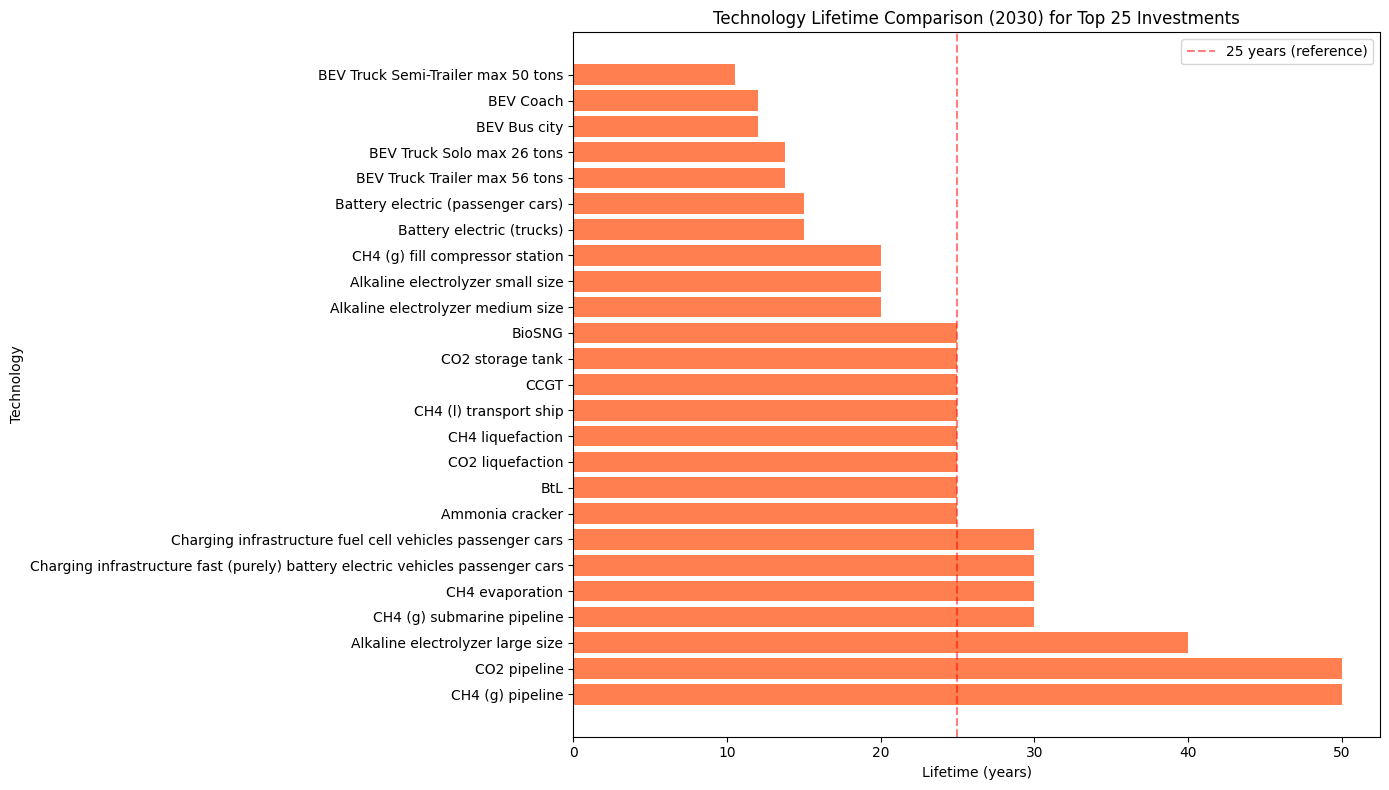

In [48]:
# Lifetime comparison across technologies
top_n_lifetime_df = costs[costs["parameter"] == "lifetime"].copy().head(n_top_investment)
top_n_lifetime_df = top_n_lifetime_df.sort_values("value", ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(top_n_lifetime_df["technology"], top_n_lifetime_df["value"], color="coral")
ax.set_xlabel("Lifetime (years)")
ax.set_ylabel("Technology")
ax.set_title(f"Technology Lifetime Comparison (2030) for Top {n_top_investment} Investments")
ax.axvline(
    x=n_top_investment,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="25 years (reference)",
)
ax.legend()
plt.tight_layout()
plt.show()

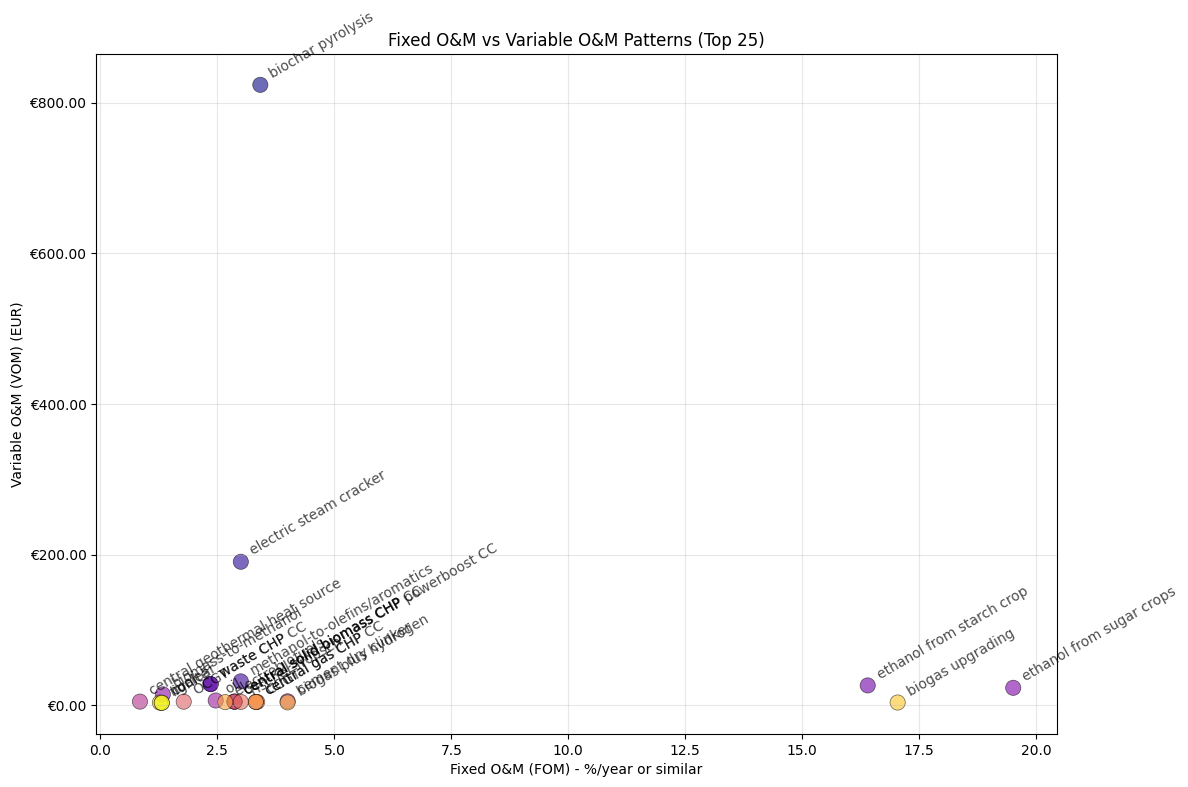

In [ ]:
# FOM (Fixed O&M) vs VOM (Variable O&M) patterns
fom_df = costs[costs["parameter"] == "FOM"][["technology", "value"]].rename(
    columns={"value": "FOM"}
)
vom_df = costs[costs["parameter"] == "VOM"][["technology", "value"]].rename(
    columns={"value": "VOM"}
)

# Merge the two datasets
om_df = pd.merge(fom_df, vom_df, on="technology", how="inner")

# Get top n_top_investment by VOM
top_n_om = om_df.nlargest(n_top_investment, "VOM")

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    top_n_om["FOM"],
    top_n_om["VOM"],
    s=120,
    alpha=0.6,
    c=range(len(top_n_om)),
    cmap="plasma",
    edgecolors="black",
    linewidth=0.5,
)
ax.set_xlabel("Fixed O&M (FOM) - %/year or similar")
ax.set_ylabel("Variable O&M (VOM) (EUR)")

# Format y-axis as euros
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.2f}"))

ax.set_title(f"Fixed O&M vs Variable O&M Patterns (Top {n_top_investment})")
ax.grid(True, alpha=0.3)

# Add labels for all points
for idx, row in top_n_om.iterrows():
    ax.annotate(
        row["technology"],
        (row["FOM"], row["VOM"]),
        fontsize=10,
        alpha=0.7,
        xytext=(5, 5),
        textcoords="offset points",
        rotation=30,
    )

plt.tight_layout()
plt.show()

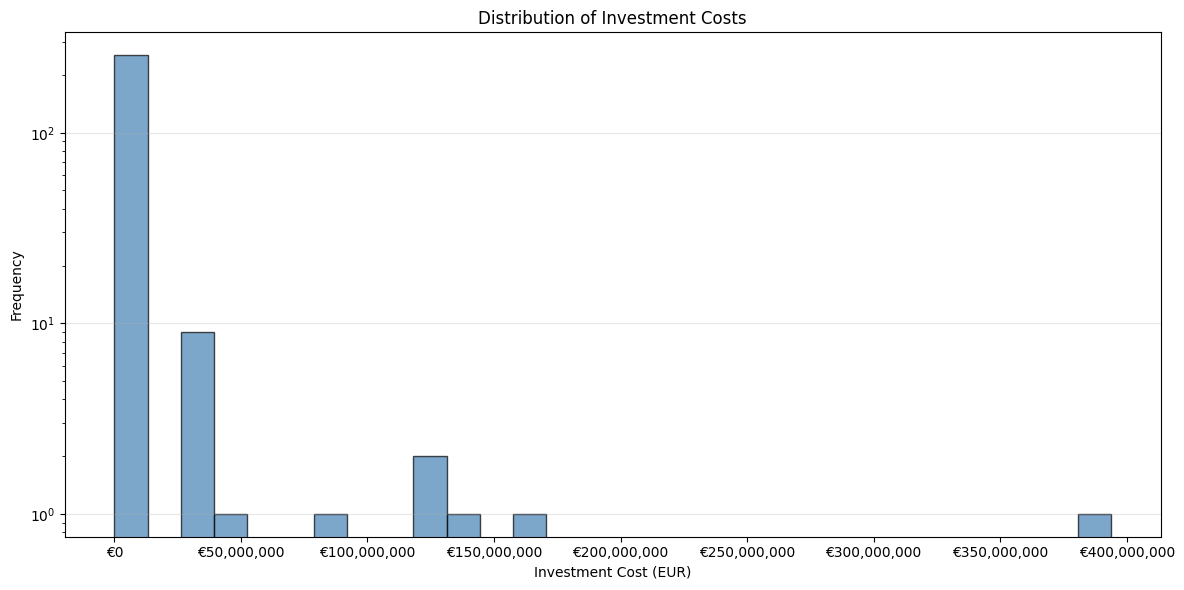

In [ ]:
# Distribution of Investment costs
investment_df = costs[costs["parameter"] == "investment"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(investment_df["value"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_xlabel("Investment Cost (EUR)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Investment Costs")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{x:,.0f}"))
ax.set_yscale("log")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

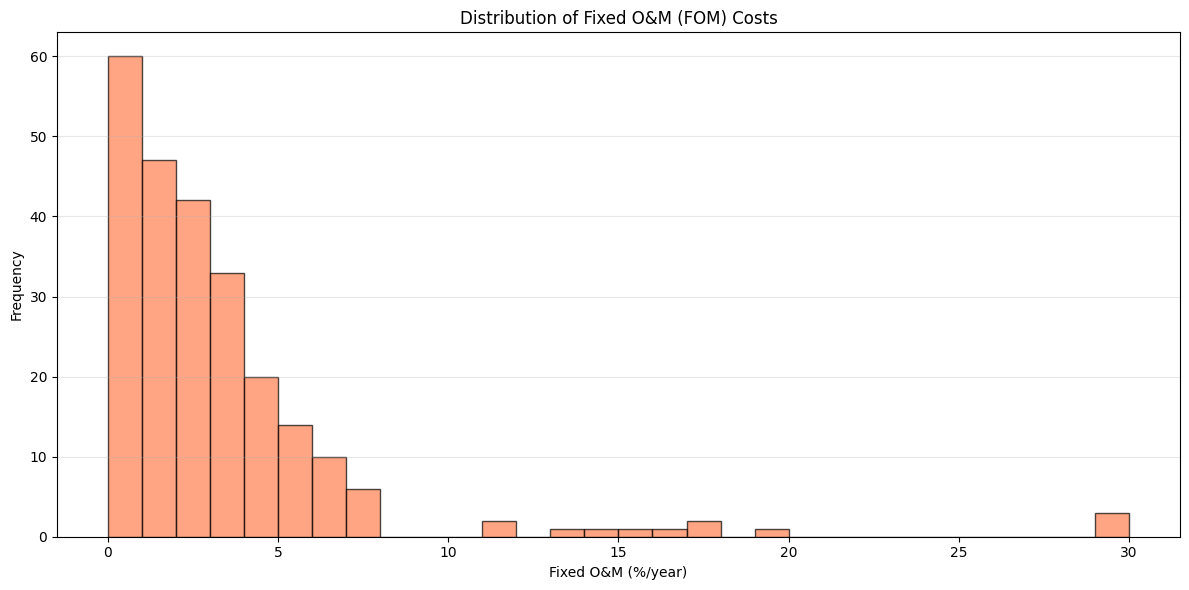

In [ ]:
# Distribution of FOM (Fixed O&M) costs
fom_df = costs[costs["parameter"] == "FOM"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(fom_df["value"], bins=30, color="coral", edgecolor="black", alpha=0.7)
ax.set_xlabel("Fixed O&M (%/year)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Fixed O&M (FOM) Costs")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

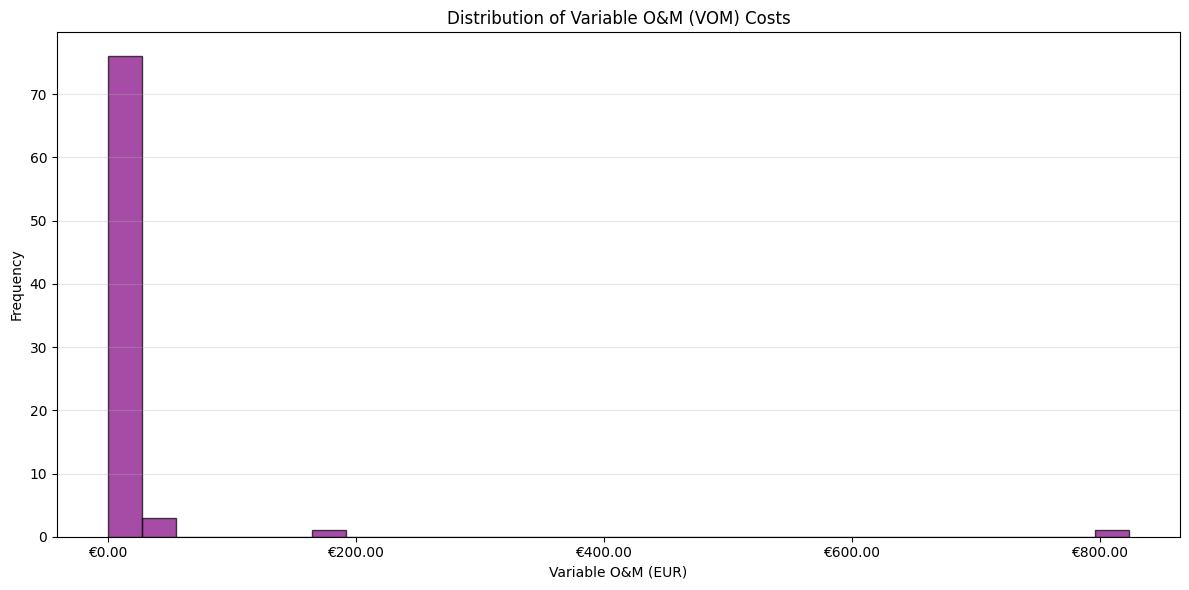

In [ ]:
# Distribution of VOM (Variable O&M) costs
vom_df = costs[costs["parameter"] == "VOM"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(vom_df["value"], bins=30, color="purple", edgecolor="black", alpha=0.7)
ax.set_xlabel("Variable O&M (EUR)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Variable O&M (VOM) Costs")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"€{x:,.2f}"))
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

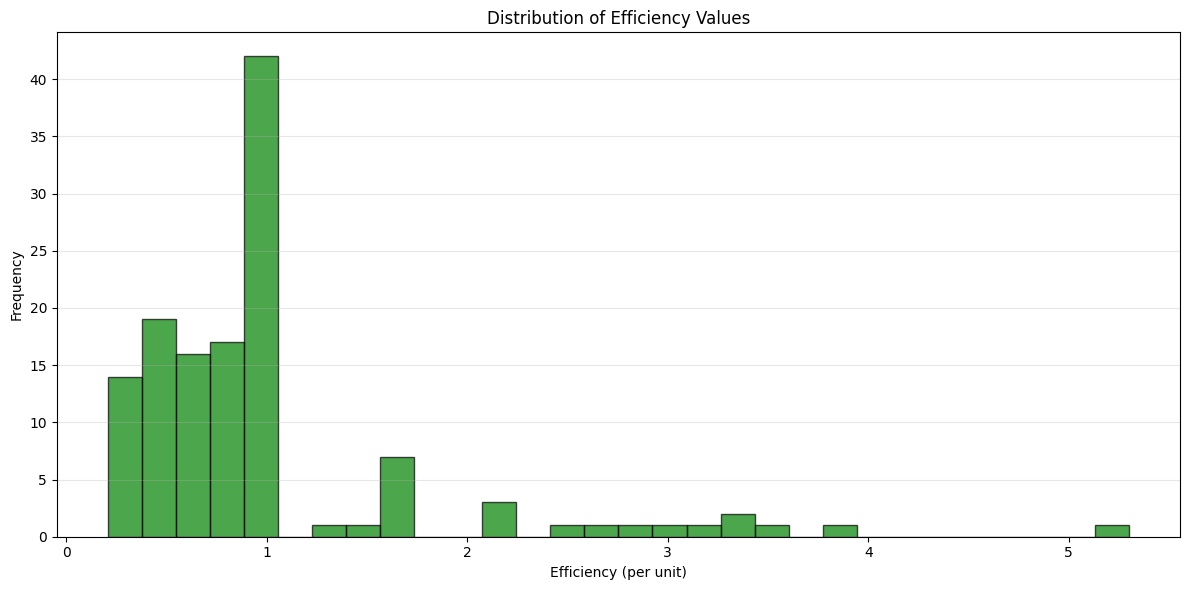

In [ ]:
# Distribution of Efficiency
efficiency_df = costs[costs["parameter"] == "efficiency"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(efficiency_df["value"], bins=30, color="green", edgecolor="black", alpha=0.7)
ax.set_xlabel("Efficiency (per unit)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Efficiency Values")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

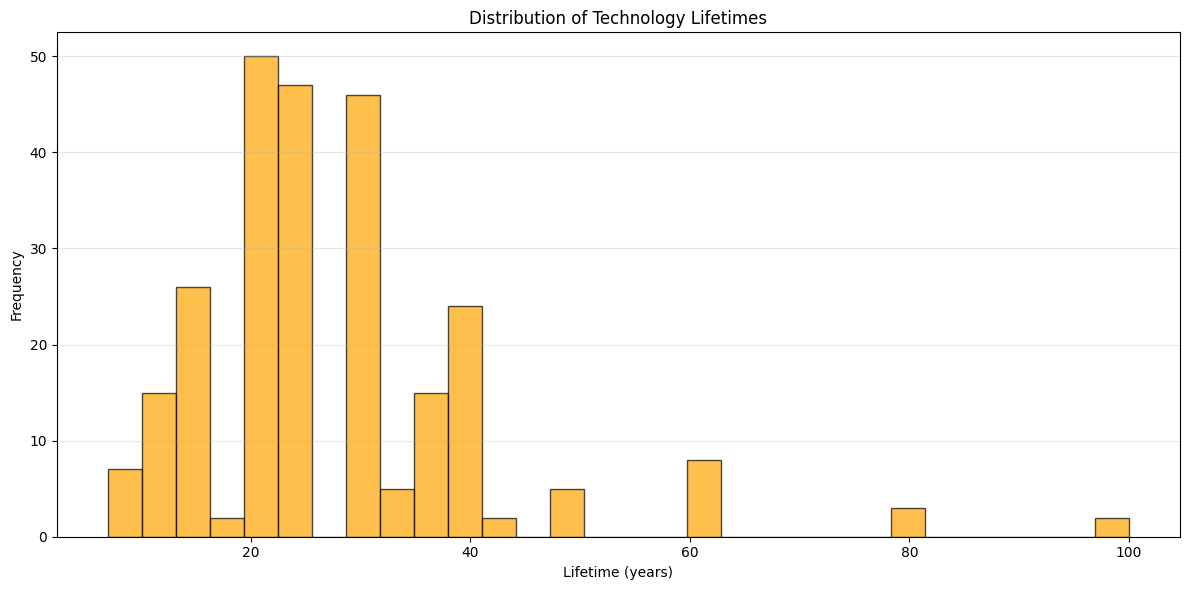

In [ ]:
# Distribution of Lifetime
lifetime_df = costs[costs["parameter"] == "lifetime"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(lifetime_df["value"], bins=30, color="orange", edgecolor="black", alpha=0.7)
ax.set_xlabel("Lifetime (years)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Technology Lifetimes")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

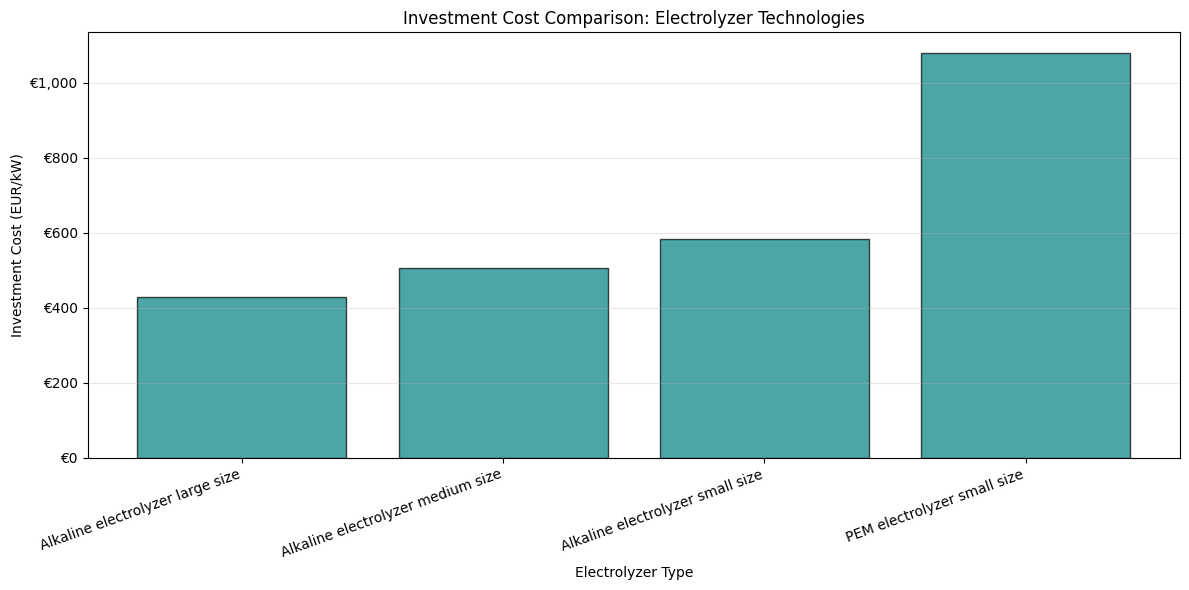

In [61]:
# Compare electrolyzer types
electrolyzer_tech = costs[costs["technology"].str.contains("electrolyzer", case=False, na=False)]

# Get investment costs for electrolyzers
electrolyzer_inv = electrolyzer_tech[electrolyzer_tech["parameter"] == "investment"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    electrolyzer_inv["technology"],
    electrolyzer_inv["value"],
    color="teal",
    alpha=0.7,
    edgecolor="black",
)
ax.set_xlabel("Electrolyzer Type")
ax.set_ylabel("Investment Cost (EUR/kW)")
ax.set_title("Investment Cost Comparison: Electrolyzer Technologies")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.0f}"))
plt.xticks(rotation=20, ha="right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

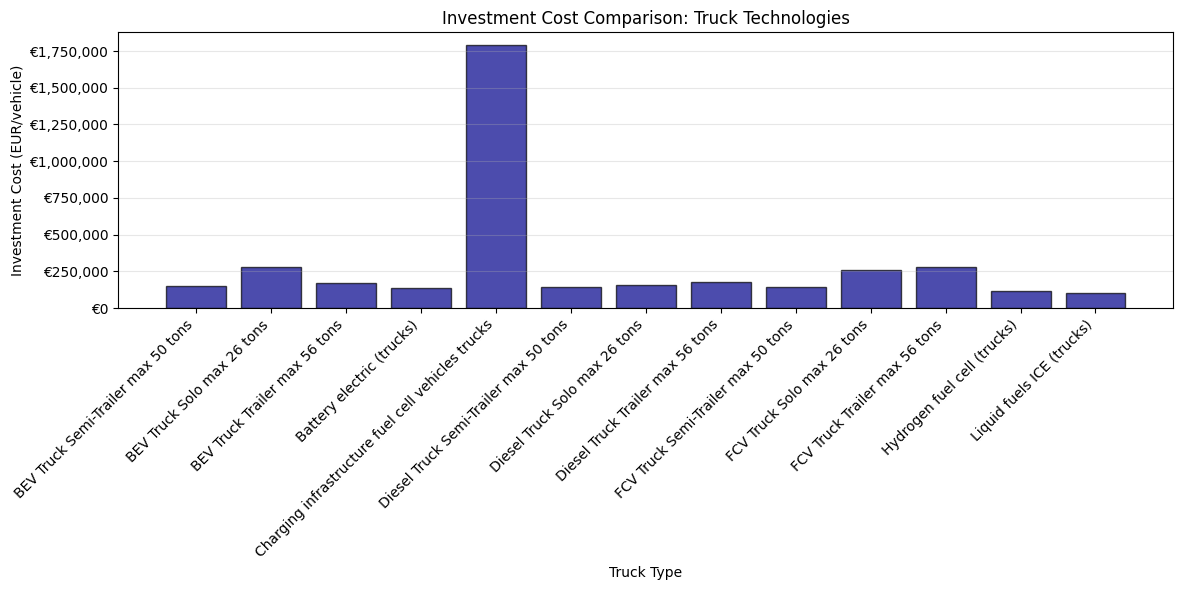

In [57]:
# Compare truck types
truck_tech = costs[costs["technology"].str.contains("Truck", case=False, na=False)]

# Get investment costs for trucks
truck_inv = truck_tech[truck_tech["parameter"] == "investment"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(truck_inv["technology"], truck_inv["value"], color="darkblue", alpha=0.7, edgecolor="black")
ax.set_xlabel("Truck Type")
ax.set_ylabel("Investment Cost (EUR/vehicle)")
ax.set_title("Investment Cost Comparison: Truck Technologies")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.0f}"))
plt.xticks(rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

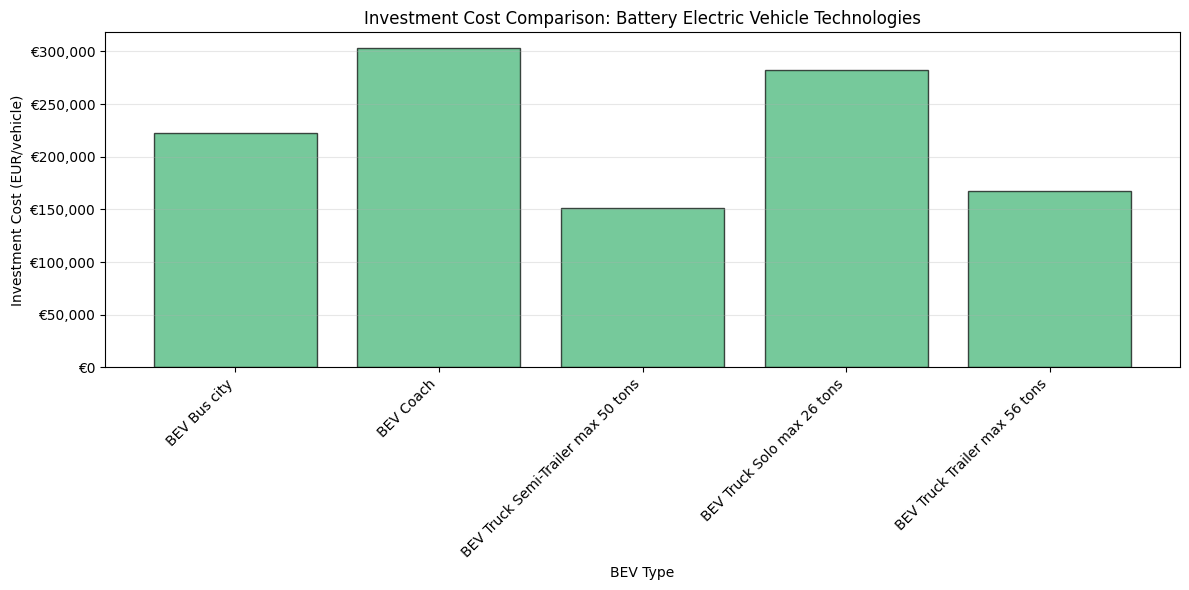

In [58]:
# Compare battery electric vehicle types
bev_tech = costs[costs["technology"].str.contains("BEV", case=False, na=False)]

# Get investment costs for BEV
bev_inv = bev_tech[bev_tech["parameter"] == "investment"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    bev_inv["technology"], bev_inv["value"], color="mediumseagreen", alpha=0.7, edgecolor="black"
)
ax.set_xlabel("BEV Type")
ax.set_ylabel("Investment Cost (EUR/vehicle)")
ax.set_title("Investment Cost Comparison: Battery Electric Vehicle Technologies")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"€{y:,.0f}"))
plt.xticks(rotation=45, ha="right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()